<div align="center">

<h2 style="color:#E50914;">
<strong><em>Netflix: A Data-Driven Exploration</em></strong>
</h2>

</div>

In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv('../data/netflix_cleaned.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_month_name,duration_value,duration_minutes,seasons,content_age,maturity_bucket
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,September,90.0,90.0,NaN,1.0,Teens / YA
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September,2.0,NaN,2.0,0.0,Mature / Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,September,1.0,NaN,1.0,0.0,Mature / Adult
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,September,1.0,NaN,1.0,0.0,Mature / Adult
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,September,2.0,NaN,2.0,0.0,Mature / Adult


#### Movies vs TV Shows

In [4]:
type_counts = df["type"].value_counts()

type_percentage = df["type"].value_counts(normalize=True).mul(100).round(2)

type = pd.DataFrame(
    {
        "type_count": type_counts,
        "type_percentage": type_percentage
    }
)

print(type)

         type_count  type_percentage
type                                
Movie          6131            69.62
TV Show        2676            30.38


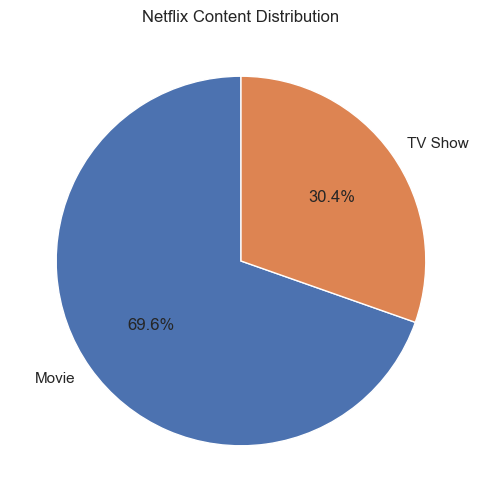

In [5]:
plt.figure(figsize=(10,6))

type_counts.plot(
    kind='pie',
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Netflix Content Distribution")
plt.ylabel("")

plt.show()

### Content Analysis

#### Content Added Over Time

In [6]:
content_by_year = df["added_year"].value_counts().sort_index()

content_by_year

added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

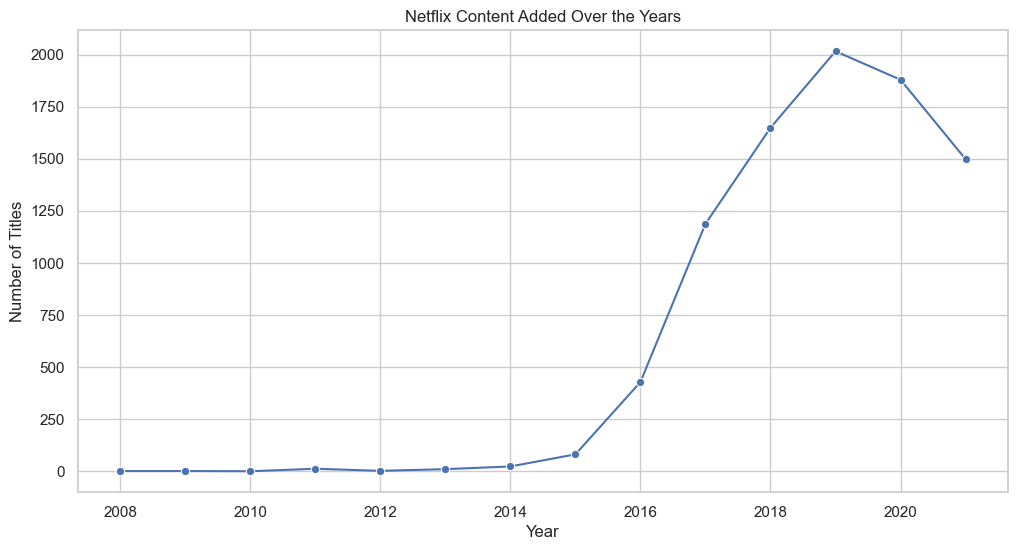

In [7]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=content_by_year.index,
    y=content_by_year.values,
    marker='o'
)

plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

#### Movies vs TV Shows over Time

In [8]:
year_type = df.groupby(["added_year", "type"]).size().unstack(fill_value=0)

year_type

type,Movie,TV Show
added_year,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,5
2014.0,19,5
2015.0,56,26
2016.0,253,176


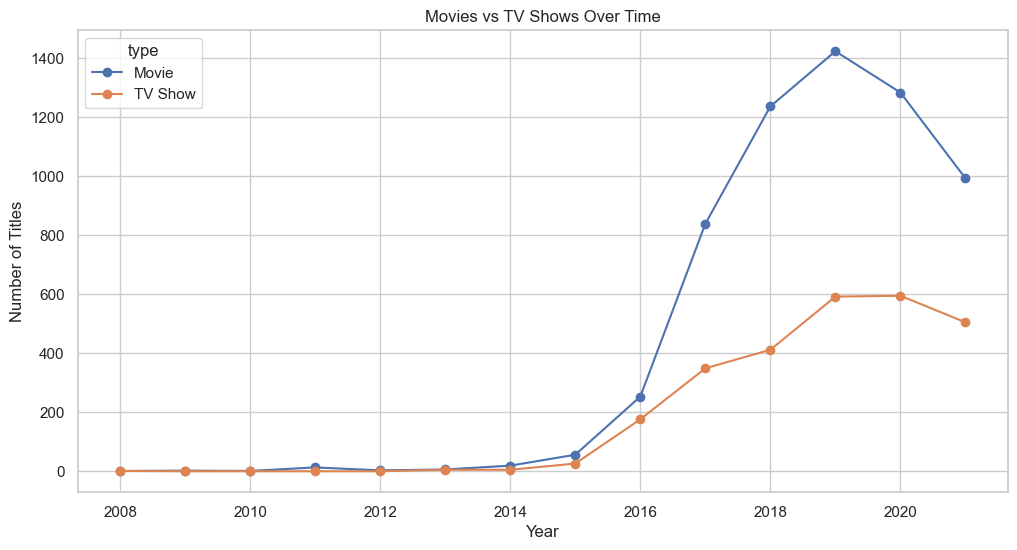

In [9]:
year_type.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

#### Peak Year

In [10]:
peak_year = content_by_year.idxmax()
peak_count = content_by_year.max()

print("Peak Year:", peak_year)
print("Titles Added:", peak_count)

Peak Year: 2019.0
Titles Added: 2016


#### Content Age Analysis

In [11]:
df["content_age"].describe()

count    8797.000000
mean        4.688417
std         8.786998
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age, dtype: float64

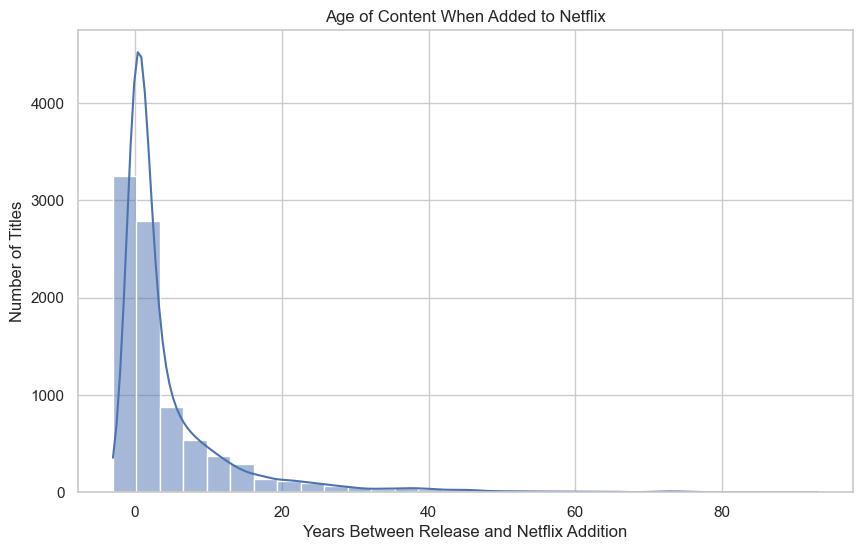

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="content_age",
    bins=30,
    kde=True
)

plt.title("Age of Content When Added to Netflix")
plt.xlabel("Years Between Release and Netflix Addition")
plt.ylabel("Number of Titles")

plt.show()

#### Content Age by type

In [13]:
df.groupby("type")["content_age"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
type,,,,
Movie,5.727777,2.0,-1.0,75.0
TV Show,2.298200,0.0,-3.0,93.0


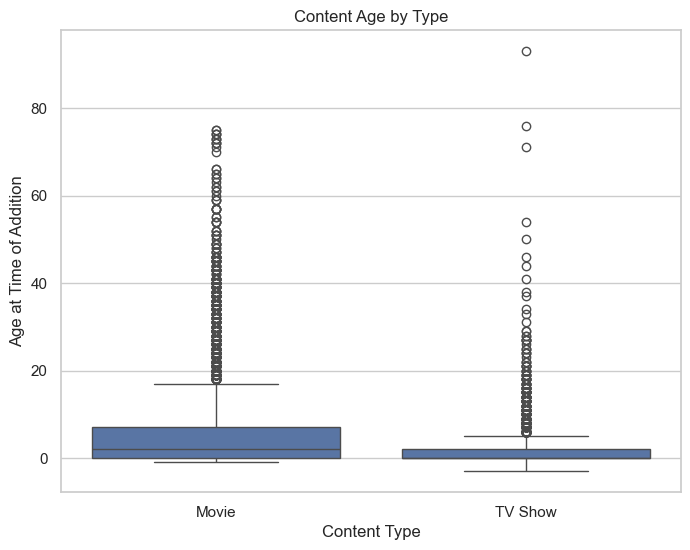

In [14]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="type",
    y="content_age"
)

plt.title("Content Age by Type")
plt.xlabel("Content Type")
plt.ylabel("Age at Time of Addition")

plt.show()

### Rating Analysis

In [15]:
rating_counts = df["rating"].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1
Name: count, dtype: int64

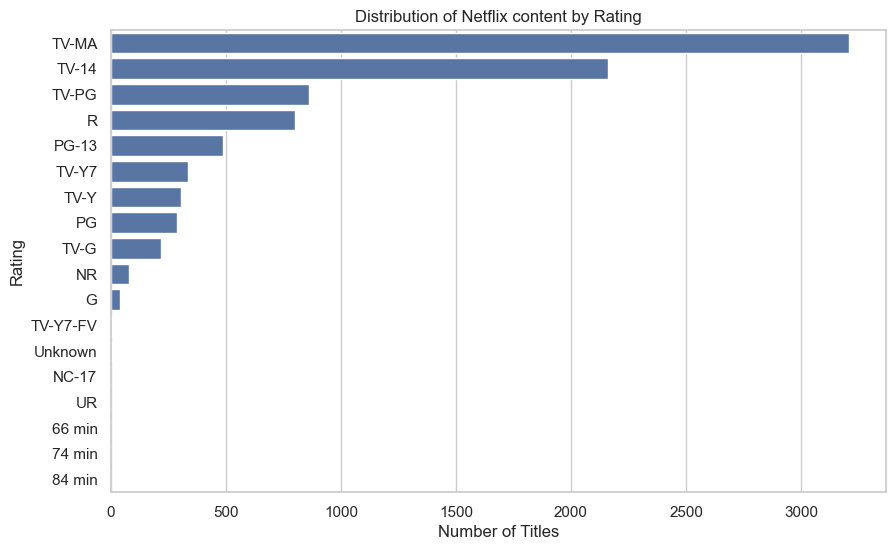

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title("Distribution of Netflix content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

In [17]:
most_common_rating = df["rating"].value_counts().idxmax()

print("Most Common Rating:", most_common_rating)

Most Common Rating: TV-MA


#### Rating by Content Type

In [18]:
rating_type = df.groupby(["rating", "type"]).size().unstack(fill_value=0)

rating_type

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


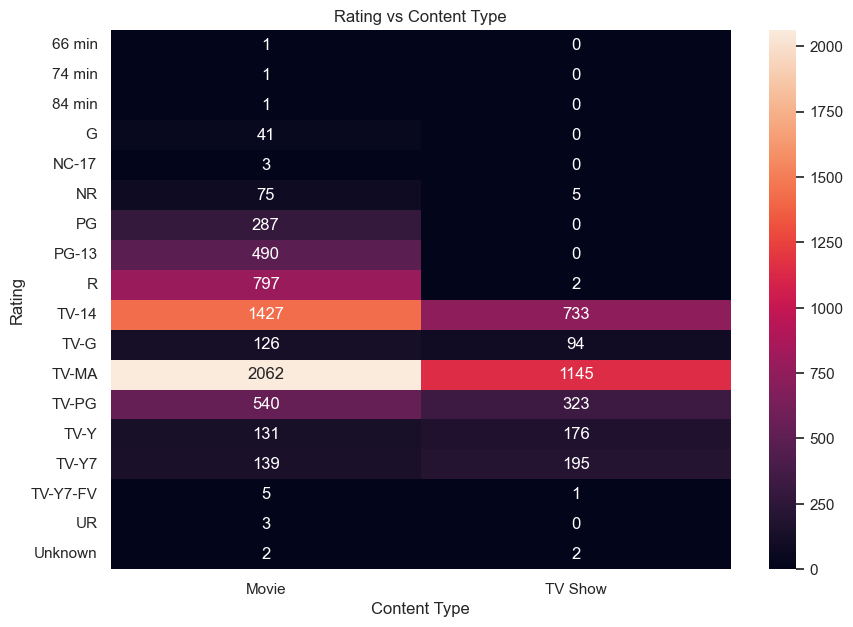

In [19]:
plt.figure(figsize=(10,7))

sns.heatmap(
    rating_type,
    annot=True,
    fmt="d"
)

plt.title("Rating vs Content Type")
plt.xlabel("Content Type")
plt.ylabel("Rating")

plt.show()

### Genre Analysis

In [20]:
genre_df = df.copy()

genre_df["genre"] = genre_df["listed_in"].str.split(", ")

In [21]:
genre_df[["title", "listed_in", "genre"]].head()

,title,listed_in,genre
0,Dick Johnson Is Dead,Documentaries,[Documentaries]
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries","[International TV Shows, TV Dramas, TV Mysteries]"
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act...","[Crime TV Shows, International TV Shows, TV Ac..."
3,Jailbirds New Orleans,"Docuseries, Reality TV","[Docuseries, Reality TV]"
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ...","[International TV Shows, Romantic TV Shows, TV..."


#### Explode Genres

In [22]:
genre_exploded = genre_df.explode("genre")

In [23]:
genre_exploded[
    ["title", "type", "genre"]
].head(10)

,title,type,genre
0,Dick Johnson Is Dead,Movie,Documentaries
1,Blood & Water,TV Show,International TV Shows
1,Blood & Water,TV Show,TV Dramas
1,Blood & Water,TV Show,TV Mysteries
2,Ganglands,TV Show,Crime TV Shows
2,Ganglands,TV Show,International TV Shows
2,Ganglands,TV Show,TV Action & Adventure
3,Jailbirds New Orleans,TV Show,Docuseries
3,Jailbirds New Orleans,TV Show,Reality TV
4,Kota Factory,TV Show,International TV Shows


#### Top Genres

In [24]:
genre_counts = genre_exploded["genre"].value_counts()

genre_counts.head(20)

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64

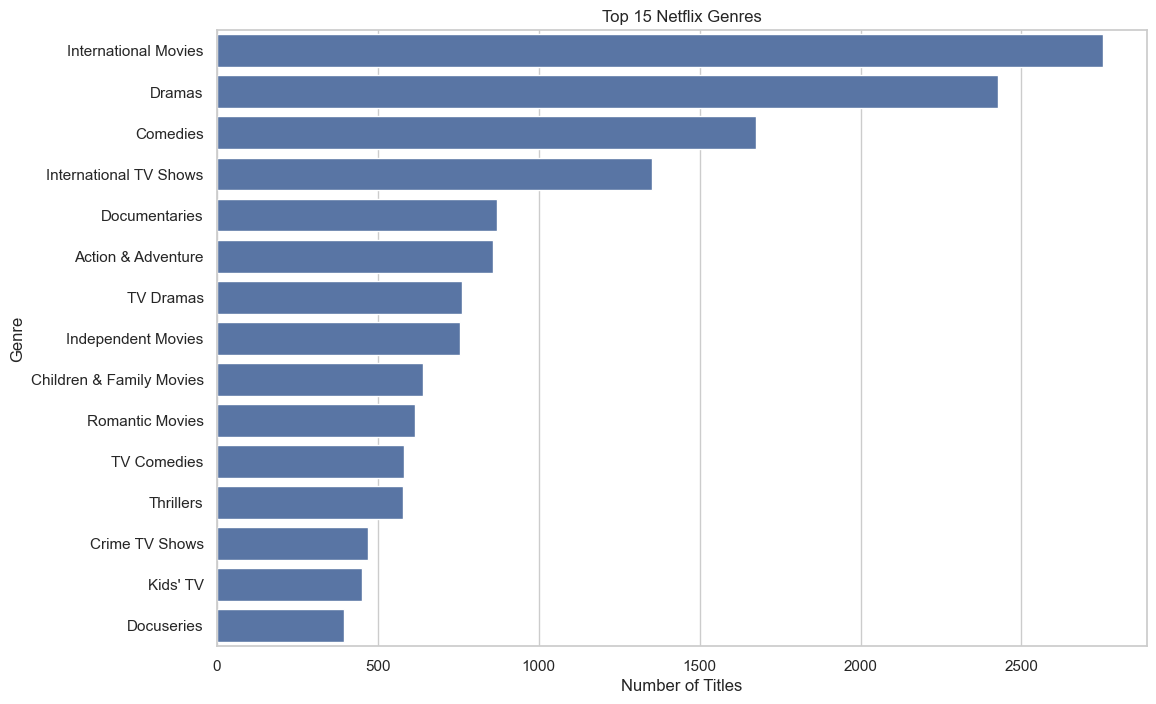

In [25]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=genre_counts.head(15).values,
    y=genre_counts.head(15).index
)

plt.title("Top 15 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

#### Most Popular Genre

In [26]:
most_common_genre = genre_counts.idxmax()

print("Most Common genre:", most_common_genre)
print("Number of Titles:", genre_counts.max())

Most Common genre: International Movies
Number of Titles: 2752


#### Genre by Content Type

In [27]:
genre_type = (
    genre_exploded
                .groupby(["genre", "type"])
                .size()
                .unstack(fill_value=0)
)

genre_type

type,Movie,TV Show
genre,,
Action & Adventure,859,0
Anime Features,71,0
Anime Series,0,176
British TV Shows,0,253
Children & Family Movies,641,0
Classic & Cult TV,0,28
Classic Movies,116,0
Comedies,1674,0
Crime TV Shows,0,470


#### Top 15 by Movies

In [28]:
genre_type.sort_values(
    by="Movie",
    ascending=False
).head(15)

type,Movie,TV Show
genre,,
International Movies,2752,0
Dramas,2427,0
Comedies,1674,0
Documentaries,869,0
Action & Adventure,859,0
Independent Movies,756,0
Children & Family Movies,641,0
Romantic Movies,616,0
Thrillers,577,0


#### Top 15 by TV Shows

In [29]:
genre_type.sort_values(
    by="TV Show",
    ascending=False
).head(15)

type,Movie,TV Show
genre,,
International TV Shows,0,1351
TV Dramas,0,763
TV Comedies,0,581
Crime TV Shows,0,470
Kids' TV,0,451
Docuseries,0,395
Romantic TV Shows,0,370
Reality TV,0,255
British TV Shows,0,253


#### Genre Comparison Visualization

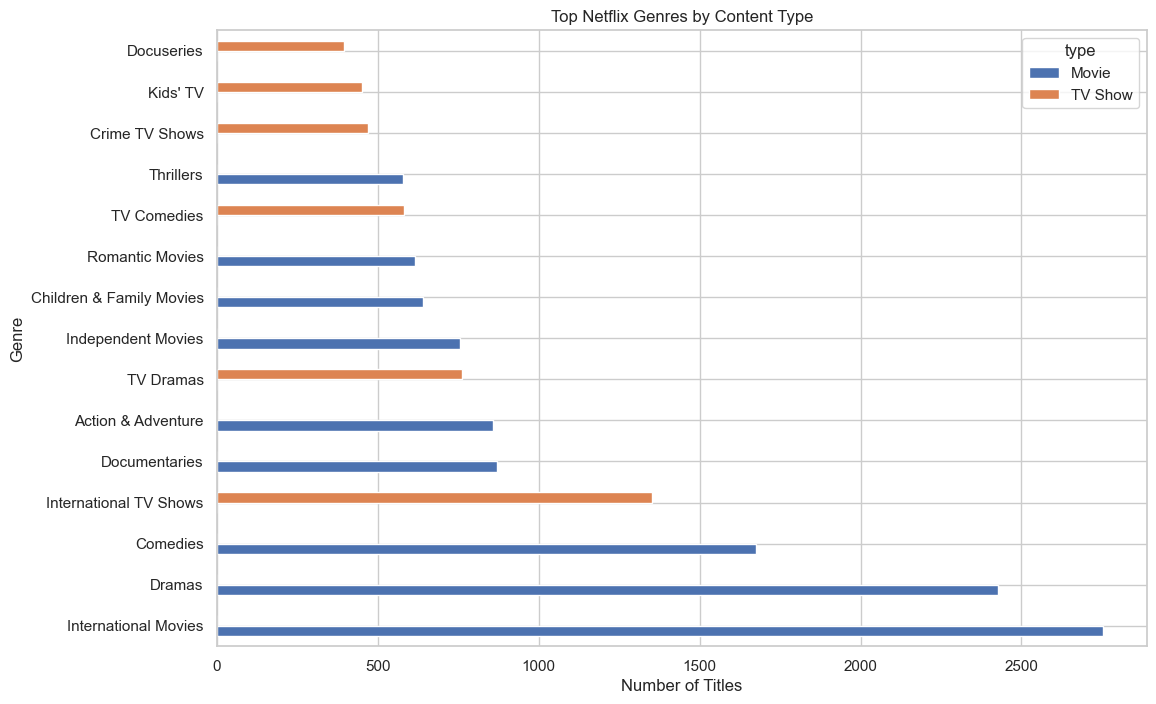

In [30]:
top_genres = genre_counts.head(15).index

genre_type_top = genre_type.loc[top_genres]

genre_type_top.plot(
    kind="barh",
    figsize=(12,8),
    
)

plt.title("Top Netflix Genres by Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

#### Genre x Rating

In [31]:
genre_rating = pd.crosstab(
    genre_exploded["genre"],
    genre_exploded["rating"]
)
genre_rating.head()

rating,66 min,74 min,84 min,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR,Unknown
genre,,,,,,,,,,,,,,,,,,
Action & Adventure,0,0,0,1,0,9,32,148,220,213,0,201,33,0,0,1,1,0
Anime Features,0,0,0,0,0,0,5,4,0,23,1,15,19,0,4,0,0,0
Anime Series,0,0,0,0,0,0,0,0,0,71,0,59,17,2,26,0,0,1
British TV Shows,0,0,0,0,0,2,0,0,0,46,17,108,55,20,5,0,0,0
Children & Family Movies,0,0,0,33,0,0,195,11,0,18,51,1,85,113,129,5,0,0


#### Major Genres

In [32]:
top_10_genres = genre_counts.head(10).index

genre_rating_top = genre_rating.loc[
    top_10_genres
]

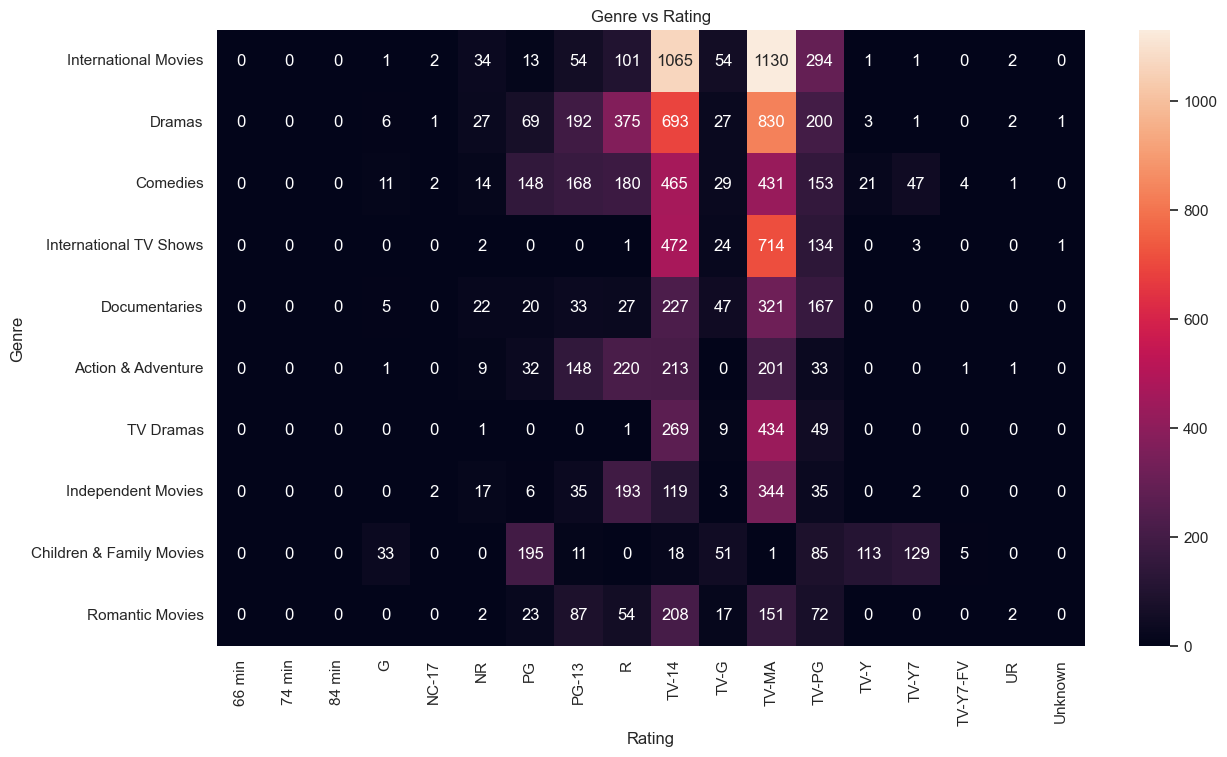

In [33]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    genre_rating_top,
    annot=True,
    fmt="d"
)

plt.title("Genre vs Rating")
plt.xlabel("Rating")
plt.ylabel("Genre")

plt.show()

### Country Analysis

In [34]:
country_df = df.copy()

country_df["country_list"] = country_df["country"].str.split(", ")

In [35]:
country_exploded = country_df.explode("country_list")

country_exploded[
    ["title", "country", "country_list"]
].head(10)

,title,country,country_list
0,Dick Johnson Is Dead,United States,United States
1,Blood & Water,South Africa,South Africa
2,Ganglands,Unknown,Unknown
3,Jailbirds New Orleans,Unknown,Unknown
4,Kota Factory,India,India
5,Midnight Mass,Unknown,Unknown
6,My Little Pony: A New Generation,Unknown,Unknown
7,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",United States
7,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",Ghana
7,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",Burkina Faso


#### Top Content Producing Countries

In [36]:
country_counts = country_exploded["country_list"].value_counts()

country_counts.head(20)

country_list
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Name: count, dtype: int64

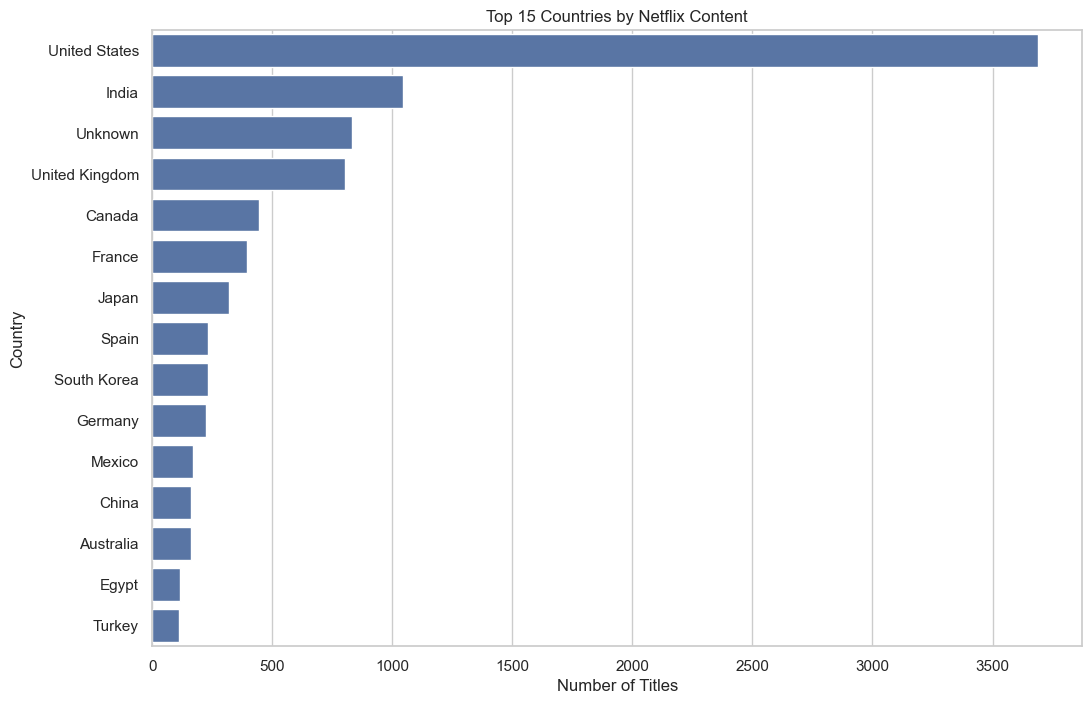

In [37]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=country_counts.head(15).values,
    y=country_counts.head(15).index
)

plt.title("Top 15 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

#### Most Productive Country

In [38]:
top_country = country_counts.idxmax()

print("Top content-producing country:", top_country)
print("Number of Titles:", country_counts.max())

Top content-producing country: United States
Number of Titles: 3689


#### Country by Content Type

In [39]:
country_type = country_exploded.groupby(["country_list", "type"]).size().unstack(fill_value=0)

country_type

type,Movie,TV Show
country_list,,
,1,1
Afghanistan,1,0
Albania,1,0
Algeria,3,0
Angola,1,0
...,...,...
Vatican City,1,0
Venezuela,4,0
Vietnam,7,0


#### Top Movies Producing Countries

In [40]:
country_type.sort_values(
    by="Movie",
    ascending=False
).head(15)

type,Movie,TV Show
country_list,,
United States,2751,938
India,962,84
United Kingdom,532,272
Unknown,440,391
Canada,319,126
France,303,90
Germany,182,44
Spain,171,61
Japan,119,199


#### Top TV Show Producing Countries

In [41]:
country_type.sort_values(
    by="TV Show",
    ascending=False
).head(15)

type,Movie,TV Show
country_list,,
United States,2751,938
Unknown,440,391
United Kingdom,532,272
Japan,119,199
South Korea,61,170
Canada,319,126
France,303,90
India,962,84
Taiwan,19,70


#### Country x Type Visualization

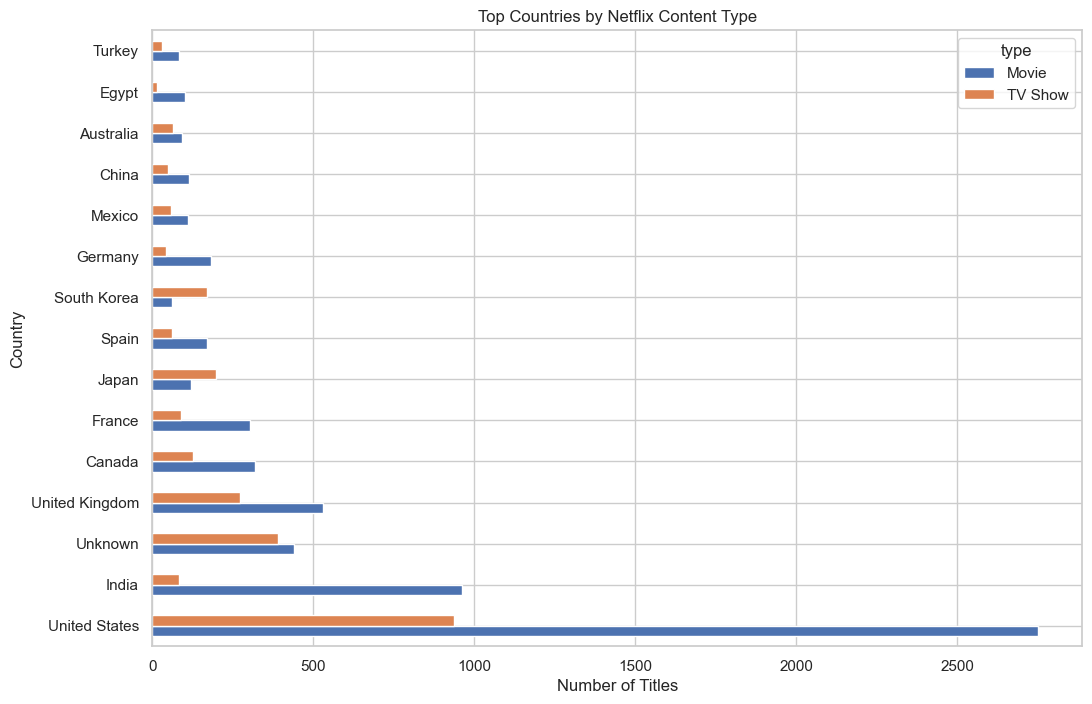

In [42]:
top_country = country_counts.head(15).index

country_type_top = country_type.loc[top_country]

country_type_top.plot(
    kind="barh",
    figsize=(12, 8)
)

plt.title("Top Countries by Netflix Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

#### Country x Genre

In [43]:
country_genre = (
    country_exploded[
        ["country_list", "title", "listed_in"]
    ]
    .copy()
)

country_genre["genre"] = (
    country_genre["listed_in"]
    .str.split(", ")
)

country_genre = country_genre.explode("genre")

In [44]:
country_genre_count = pd.crosstab(
    country_genre["country_list"],
    country_genre["genre"]
)

top_10_countries = country_counts.head(10).index

country_genre_top = country_genre_count.loc[
    top_10_countries
]

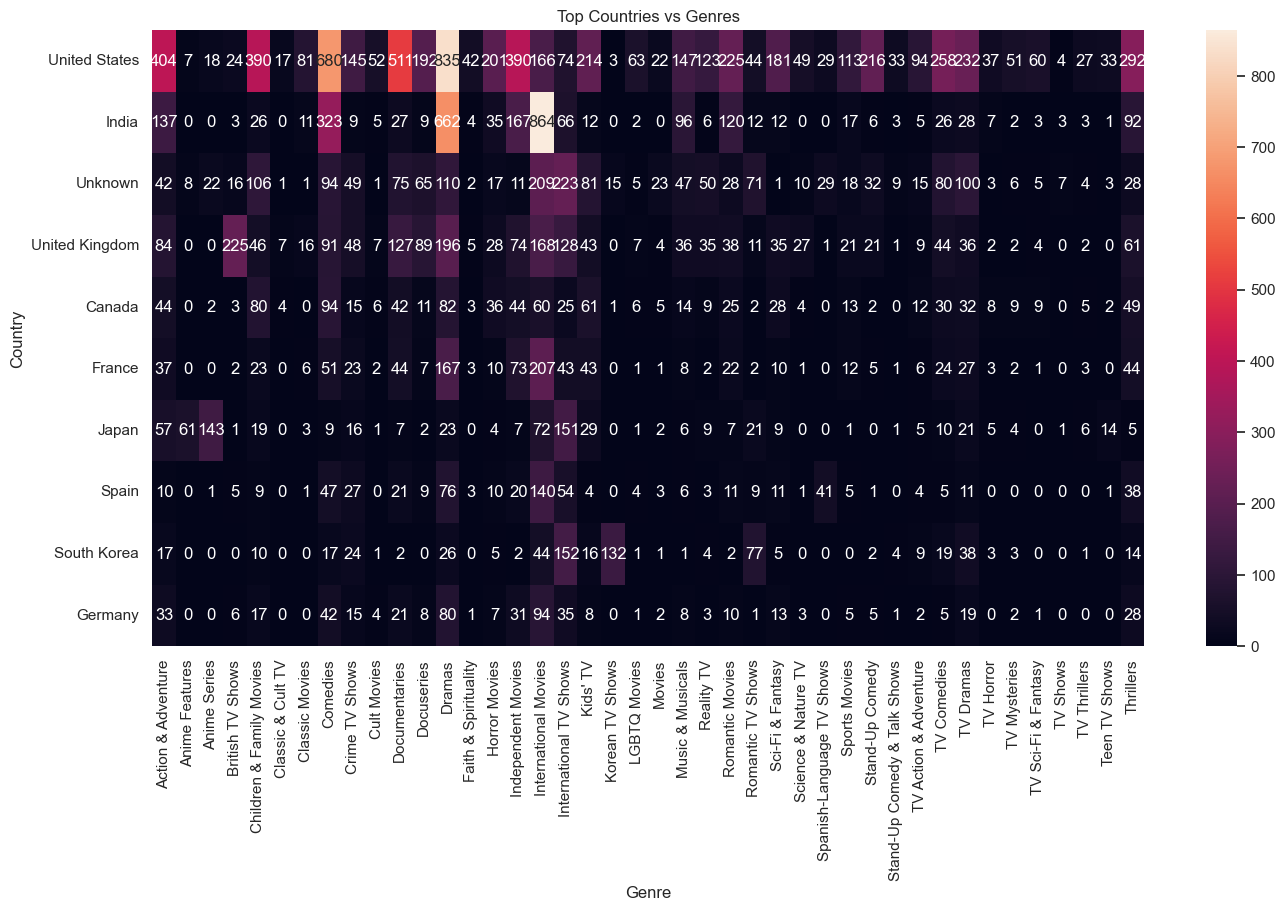

In [45]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    country_genre_top,
    annot=True,
    fmt="d"
)

plt.title("Top Countries vs Genres")
plt.xlabel("Genre")
plt.ylabel("Country")

plt.show()

### Director Analysis

In [46]:
director_df = df[df["director"] != "Unknown"].copy()

director_df["director_list"] = director_df["director"].str.split(", ")

director_exploded = director_df.explode("director_list")

director_exploded[
    ["title", "director_list"]
].head(10)

,title,director_list
0,Dick Johnson Is Dead,Kirsten Johnson
2,Ganglands,Julien Leclercq
5,Midnight Mass,Mike Flanagan
6,My Little Pony: A New Generation,Robert Cullen
6,My Little Pony: A New Generation,José Luis Ucha
7,Sankofa,Haile Gerima
8,The Great British Baking Show,Andy Devonshire
9,The Starling,Theodore Melfi
11,Bangkok Breaking,Kongkiat Komesiri
12,Je Suis Karl,Christian Schwochow


#### Top Directors

In [47]:
directors_counts = director_exploded["director_list"].value_counts()

directors_counts.head(20)

director_list
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Steven Spielberg       11
Don Michael Paul       10
David Dhawan            9
Yılmaz Erdoğan          9
Shannon Hartman         9
Anurag Kashyap          9
Umesh Mehra             8
Hakan Algül             8
Fernando Ayllón         8
Johnnie To              8
Name: count, dtype: int64

#### Director Analysis by Content Type

In [48]:
director_type = director_exploded.groupby(["director_list", "type"]).size().unstack(fill_value=0)

director_type.sort_values(by="Movie", ascending=False).head(15)

type,Movie,TV Show
director_list,,
Rajiv Chilaka,22,0
Jan Suter,21,0
Raúl Campos,19,0
Suhas Kadav,16,0
Marcus Raboy,15,1
Jay Karas,15,0
Cathy Garcia-Molina,13,0
Jay Chapman,12,0
Youssef Chahine,12,0


### Cast / Actor Analysis

In [49]:
cast_df = df[df["cast"] != "Unknown"].copy()

cast_df["cast_list"] = cast_df["cast"].str.split(", ")

cast_exploded = cast_df.explode("cast_list")

cast_exploded[
    ["type", "title", "cast_list"]
].head(15)

,type,title,cast_list
1,TV Show,Blood & Water,Ama Qamata
1,TV Show,Blood & Water,Khosi Ngema
1,TV Show,Blood & Water,Gail Mabalane
1,TV Show,Blood & Water,Thabang Molaba
1,TV Show,Blood & Water,Dillon Windvogel
1,TV Show,Blood & Water,Natasha Thahane
1,TV Show,Blood & Water,Arno Greeff
1,TV Show,Blood & Water,Xolile Tshabalala
1,TV Show,Blood & Water,Getmore Sithole
1,TV Show,Blood & Water,Cindy Mahlangu


#### Top Actors

In [50]:
actors_count = cast_exploded["cast_list"].value_counts()

actors_count.head(20)

cast_list
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Takahiro Sakurai     32
Naseeruddin Shah     32
Rupa Bhimani         31
Om Puri              30
Akshay Kumar         30
Yuki Kaji            29
Amitabh Bachchan     28
Paresh Rawal         28
Boman Irani          27
Rajesh Kava          26
Vincent Tong         26
Andrea Libman        25
Kareena Kapoor       25
John Cleese          24
Samuel L. Jackson    24
Tara Strong          23
Jigna Bhardwaj       23
Name: count, dtype: int64

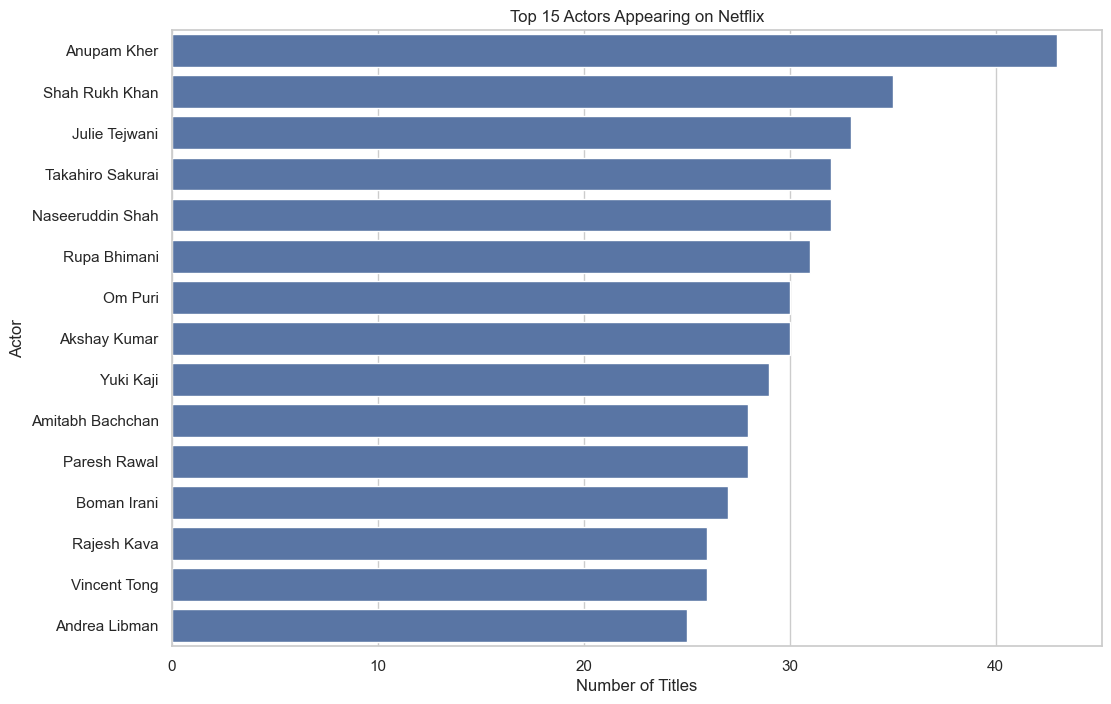

In [51]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=actors_count.head(15).values,
    y=actors_count.head(15).index
)

plt.title("Top 15 Actors Appearing on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.show()

### Movie Duration Analysis

In [52]:
movies = df[df["type"] == "Movie"].copy()
movies[
    ["title", "duration", "duration_minutes"]
].head(10)

,title,duration,duration_minutes
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0
13,Confessions of an Invisible Girl,91 min,91.0
16,Europe's Most Dangerous Man: Otto Skorzeny in ...,67 min,67.0
18,Intrusion,94 min,94.0
22,Avvai Shanmughi,161 min,161.0
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,61 min,61.0


#### Movie Duration Statistics

In [53]:
movies["duration_minutes"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [54]:
print(
    "Average Movie Duration: ", 
    round(movies["duration_minutes"].mean(),2),
    "minutes"
)

print(
    "Median Movie Duration: ",
    movies["duration_minutes"].median(), "minutes"
)

Average Movie Duration:  99.58 minutes
Median Movie Duration:  98.0 minutes


#### Movie Duration Distribution

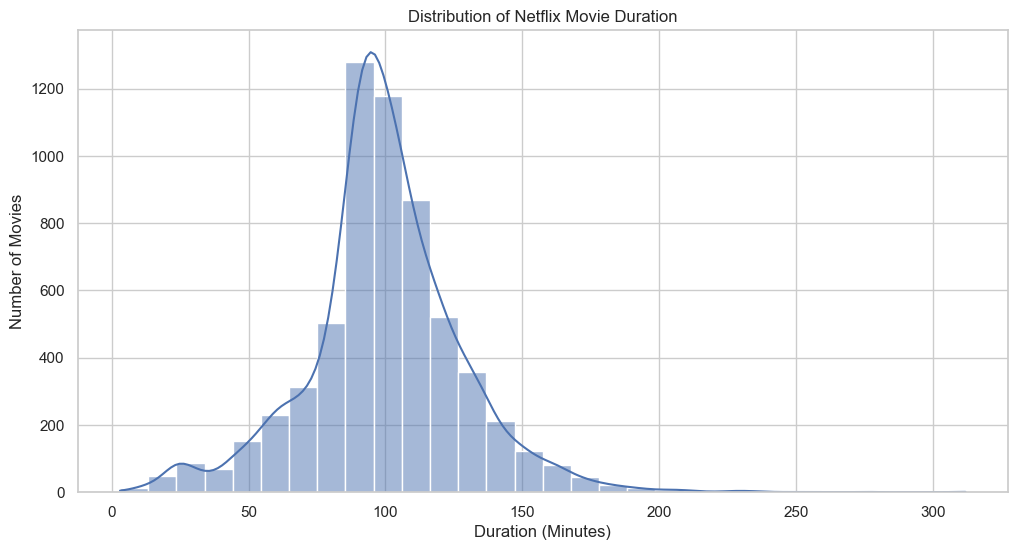

In [55]:
plt.figure(figsize=(12,6))

sns.histplot(
    x=movies["duration_minutes"],
    bins = 30,
    kde=True
)

plt.title("Distribution of Netflix Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

#### Find Longest Movies

In [56]:
movies.sort_values(
    by="duration_minutes",
    ascending=False
)[
    ["title", "duration_minutes"]
].head(10)

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0
2488,Raya and Sakina,230.0
166,Once Upon a Time in America,229.0
7932,Sangam,228.0
1019,Lagaan,224.0
4573,Jodhaa Akbar,214.0


#### Shortest Movies

In [57]:
movies.sort_values(
    by="duration_minutes"
)[
    ["title", "duration_minutes"]
].head(10)

,title,duration_minutes
3777,Silent,3.0
2713,Sol Levante,5.0
1484,Cops and Robbers,8.0
1557,Canvas,9.0
3535,American Factory: A Conversation with the Obamas,10.0
6405,Calico Critters: A Town of Dreams,11.0
2858,Calico Critters: Everyone's Big Dream Flying i...,11.0
695,Besieged Bread,12.0
3775,Cosmos Laundromat: First Cycle,12.0
4707,Zion,12.0


### TV Shows Analysis

In [58]:
tv_shows = df[df["type"] == "TV Show"].copy()

tv_shows[
    ["title", "duration", "seasons"]
].head()

,title,duration,seasons
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0


#### Season Duration

In [59]:
season_counts = tv_shows["seasons"].value_counts().sort_index()

season_counts

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64

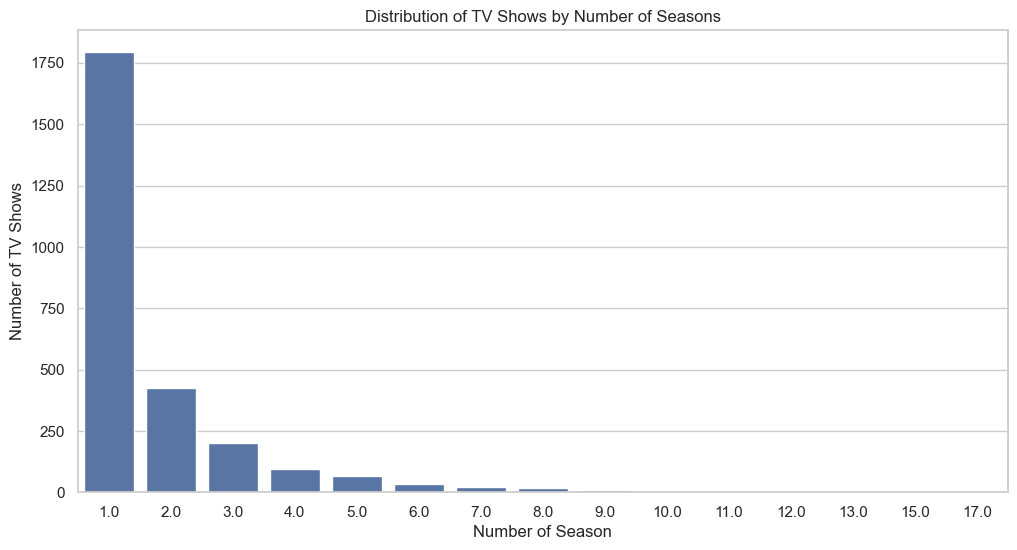

In [60]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("Distribution of TV Shows by Number of Seasons")
plt.xlabel("Number of Season")
plt.ylabel("Number of TV Shows")

plt.show()

#### Most Common Number of Season

In [61]:
most_common_season = tv_shows["seasons"].mode()[0]

print(
    "Most Common number of Seasons: ", int(most_common_season)
)

Most Common number of Seasons:  1


#### One Season TV Shows

In [62]:
one_season = tv_shows[
    tv_shows["seasons"] == 1
]

one_season_percentage = (
    len(one_season)/len(tv_shows)*100
)

print("One-Season TV Show: ", len(one_season))

print(
    f"{one_season_percentage:.2f}% of TV Shows have one season."
)

One-Season TV Show:  1793
67.00% of TV Shows have one season.


#### Movie vs TV Shows -- Release Year

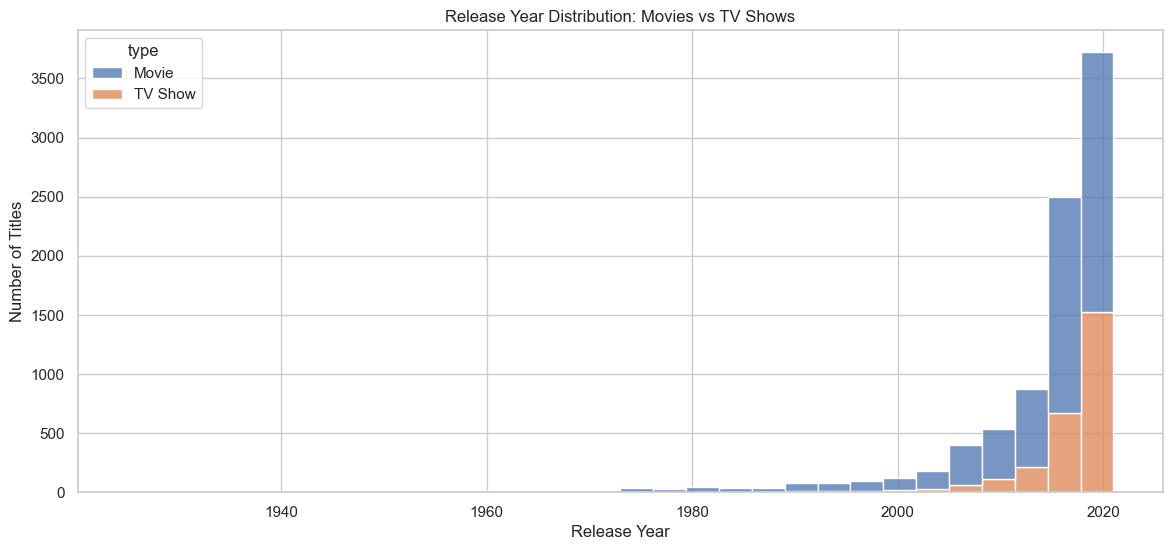

In [63]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=df,
    x="release_year",
    hue="type",
    bins=30,
    multiple="stack"
)

plt.title("Release Year Distribution: Movies vs TV Shows")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()